In [64]:
# ================================================================
# LASSO MODEL — PHASE 1: Load data & create target
# ================================================================

import pandas as pd
import numpy as np

print("Loading dataset...")

df = pd.read_csv("../output/training_data_v6_no0min_trial.csv", encoding="utf-8-sig")
print(f"   → Loaded {len(df):,} rows")

# Sort by player → season → GW
df = df.sort_values(["Player UUID", "season", "Gameweek"]).reset_index(drop=True)

# Create Target_NextGW
df["Target_NextGW"] = df.groupby(["Player UUID", "season"])["Total Points"].shift(-1)

before = len(df)
df = df.dropna(subset=["Target_NextGW"]).reset_index(drop=True)
print(f"🧹 Removed rows with no next GW target: {before - len(df)}")

df["Target_NextGW"] = df["Target_NextGW"].astype(float)

print("✔ Phase 1 complete.")


Loading dataset...
   → Loaded 25,735 rows
🧹 Removed rows with no next GW target: 2314
✔ Phase 1 complete.


In [65]:

# PHASE 2 — Build last-5-observations validation split 


print("Building last-5-observations validation split per player...")

df["Split"] = "Train"

for uuid, g in df.groupby("Player UUID", sort=False):
    last_5_idx = g.tail(5).index
    df.loc[last_5_idx, "Split"] = "Validation"

print(df["Split"].value_counts())
print("✔ Phase 2 complete.")


Building last-5-observations validation split per player...
Split
Train         19942
Validation     3479
Name: count, dtype: int64
✔ Phase 2 complete.


In [66]:

# PHASE 3 — DEBUG: Show last 5 rows per player


debug_counter = 0

for uuid, g in df.groupby("Player UUID", sort=False):
    if debug_counter < 5:
        print(f"\nPLAYER UUID: {uuid}")
        print(g.tail(5)[["season", "Gameweek", "Total Points", "Target_NextGW", "Split"]])
        print("-" * 60)
        debug_counter += 1

print("✔ Debug inspect complete.")



PLAYER UUID: 00d29d0a-98c1-4730-9e17-1d278cb660ae
     season  Gameweek  Total Points  Target_NextGW       Split
14  2023-24        32             1            1.0  Validation
15  2023-24        34             1            1.0  Validation
16  2023-24        35             1            0.0  Validation
17  2023-24        36             0            2.0  Validation
18  2023-24        37             2            2.0  Validation
------------------------------------------------------------

PLAYER UUID: 00e5b1e6-a33d-4079-aa0e-b31b4c7d2b05
     season  Gameweek  Total Points  Target_NextGW       Split
24  2024-25        33             6            1.0  Validation
25  2024-25        34             1            3.0  Validation
26  2025-26         3             3            0.0  Validation
27  2025-26         4             0            0.0  Validation
28  2025-26         5             0            1.0  Validation
------------------------------------------------------------

PLAYER UUID: 00e8f0

In [67]:

# PHASE 4 — Prepare features & target


# %%
# PHASE 4 — Prepare features & target

print("Preparing features and target for LASSO...")

df_model = df.copy()

cols_to_drop = [
    "Player UUID", "Player Name", "Web Name",
    "Player Team Name", "Opponent Name",
    "season", "Gameweek", "Split"
]

df_model = df_model.drop(columns=cols_to_drop, errors="ignore")

# Target
y = df_model["Target_NextGW"]

# Features
X = df_model.drop(columns=["Target_NextGW"], errors="ignore")

# Fix Is Home
if "Is Home" in X.columns:
    X["Is Home"] = X["Is Home"].replace(
        {True:1, False:0, "True":1, "False":0}
    ).astype(int)

# One-hot encode Position
if "Position" in X.columns:
    X["Position"] = X["Position"].fillna("Unknown")
    X = pd.get_dummies(X, columns=["Position"], drop_first=True)

# NEW: Check for missing values
missing_counts = X.isnull().sum()
if missing_counts.any():
    print("\n⚠️  Missing values detected:")
    print(missing_counts[missing_counts > 0])
    print("\n   → Filling with median...")
    X = X.fillna(X.median())
else:
    print("✅ No missing values in features")

print("\nFeature matrix shape:", X.shape)
print("✔ Phase 4 complete.")

Preparing features and target for LASSO...
✅ No missing values in features

Feature matrix shape: (23421, 47)
✔ Phase 4 complete.


C:\Users\SOFI\AppData\Local\Temp\ipykernel_1424\211450484.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Is Home"] = X["Is Home"].replace(


In [68]:

# PHASE 5 — Scaling

from sklearn.preprocessing import StandardScaler

train_mask = df["Split"] == "Train"
val_mask   = df["Split"] == "Validation"

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train = X.loc[train_mask]
X_val   = X.loc[val_mask]

y_train = y.loc[train_mask]
y_val   = y.loc[val_mask]

# Scale numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_all_scaled   = scaler.transform(X)

print("✔ Scaling complete.")
print("   → Train:", X_train_scaled.shape)
print("   → Val:  ", X_val_scaled.shape)


✔ Scaling complete.
   → Train: (19942, 47)
   → Val:   (3479, 47)


In [69]:
# %%
# PHASE 6 — Train LASSO model with improved settings

from sklearn.linear_model import LassoCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Training LASSO with GroupKFold CV...")

# Better alpha range for standardized features
alphas = np.logspace(-4, 0, 100)  # 0.0001 to 1.0

# Prepare GroupKFold to prevent player leakage
groups = df.loc[train_mask, 'Player UUID'].values
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train_scaled, y_train, groups=groups))

print(f"   → Created {len(cv_splits)} CV splits (grouped by player)")

lasso = LassoCV(
    alphas=alphas,
    cv=cv_splits,
    random_state=42,
    max_iter=10000,
    tol=1e-4,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

y_train_pred = lasso.predict(X_train_scaled)
y_val_pred   = lasso.predict(X_val_scaled)
y_all_pred   = lasso.predict(X_all_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae   = mean_absolute_error(y_val, y_val_pred)
train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
val_rmse  = mean_squared_error(y_val, y_val_pred) ** 0.5

print("\n📊 LASSO Performance:")
print(f"   • Best alpha:       {lasso.alpha_:.6f}")
print(f"   • MAE Train:        {train_mae:.4f}")
print(f"   • MAE Validation:   {val_mae:.4f}")
print(f"   • RMSE Train:       {train_rmse:.4f}")
print(f"   • RMSE Validation:  {val_rmse:.4f}")

print("✔ LASSO training complete.")

Training LASSO with GroupKFold CV...
   → Created 5 CV splits (grouped by player)


c:\Python\fpl_pipeline\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.463e+01, tolerance: 1.467e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Python\fpl_pipeline\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.143e+01, tolerance: 1.466e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Python\fpl_pipeline\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality ga


📊 LASSO Performance:
   • Best alpha:       0.015199
   • MAE Train:        2.1134
   • MAE Validation:   1.7626
   • RMSE Train:       2.9203
   • RMSE Validation:  2.5061
✔ LASSO training complete.


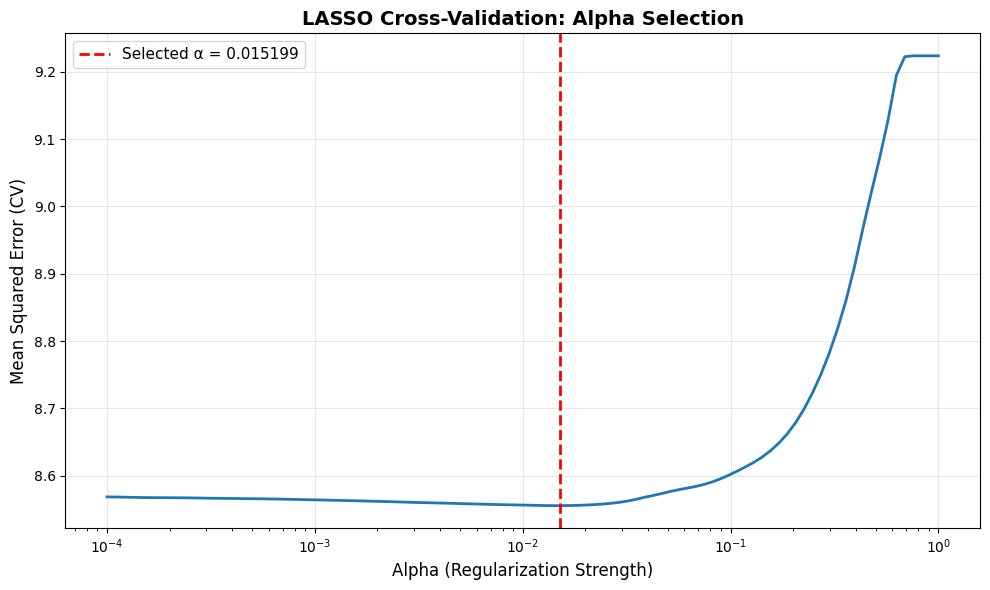


📊 Feature Selection Results:
   • Features retained:    19 / 47
   • Features eliminated:  28
   • Sparsity:            59.6%

🔝 Top 15 Most Important Features:
                      Feature  Coefficient
         Player_Season_Points     0.286175
                Avg_Threat_L5     0.229740
               Minutes Played     0.198192
          Avg_Total Points_L5     0.124217
                    ICT Index     0.109577
            Team_Total_Points    -0.090862
                       Threat     0.074406
            Avg_Creativity_L3     0.067722
        Avg_Goals Conceded_L5    -0.061541
Team_Contribution_Rank_Causal    -0.060954
          Opponent Difficulty     0.058709
                 Total Points     0.051565
                         Code    -0.051430
         Team_Total_Points_GW     0.047257
                      Is Home    -0.035854

✔ Alpha selection plot & coefficient analysis saved.


In [70]:

# PHASE 6.5 — Analyze alpha selection & coefficients

import matplotlib.pyplot as plt

# Plot alpha selection path
plt.figure(figsize=(10, 6))
plt.semilogx(lasso.alphas_, lasso.mse_path_.mean(axis=1), linewidth=2)
plt.axvline(lasso.alpha_, color='red', linestyle='--', linewidth=2, 
            label=f'Selected α = {lasso.alpha_:.6f}')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Mean Squared Error (CV)', fontsize=12)
plt.title('LASSO Cross-Validation: Alpha Selection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'alpha_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Coefficient analysis
coef_analysis = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
})

# Sort by absolute value (but don't save Abs_Coef column)
coef_analysis['_sort_key'] = coef_analysis['Coefficient'].abs()
coef_analysis = coef_analysis.sort_values('_sort_key', ascending=False)
coef_analysis = coef_analysis.drop(columns=['_sort_key'])  # Remove temporary column

non_zero = coef_analysis[coef_analysis['Coefficient'] != 0]
zero_coef = coef_analysis[coef_analysis['Coefficient'] == 0]

print(f"\n📊 Feature Selection Results:")
print(f"   • Features retained:    {len(non_zero)} / {len(coef_analysis)}")
print(f"   • Features eliminated:  {len(zero_coef)}")
print(f"   • Sparsity:            {len(zero_coef)/len(coef_analysis)*100:.1f}%")

print("\n🔝 Top 15 Most Important Features:")
print(non_zero.head(15).to_string(index=False))

# Save detailed coefficient analysis (only Feature & Coefficient columns)
coef_analysis.to_csv(OUT_DIR / "coefficient_analysis.csv", index=False, encoding="utf-8-sig")

print("\n✔ Alpha selection plot & coefficient analysis saved.")

In [71]:

# PHASE 7 — Export LASSO coefficients

from pathlib import Path

OUT_DIR = Path("../output/lasso_model")
OUT_DIR.mkdir(parents=True, exist_ok=True)

coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
})

coeff_df.to_csv(OUT_DIR / "coefficients.csv", index=False, encoding="utf-8-sig")

print("✔ Coefficients saved → coefficients.csv")
coeff_df.head(10)




✔ Coefficients saved → coefficients.csv


,Feature,Coefficient
0,Code,-0.051430
1,Minutes Played,0.198192
2,Goals Scored,0.000000
3,Assists,0.000000
4,Clean Sheet,0.000000
5,Goals Conceded,-0.004849
6,Yellow Card,-0.000000
7,Red Cards,0.000000
8,Total Points,0.051565
9,Threat,0.074406


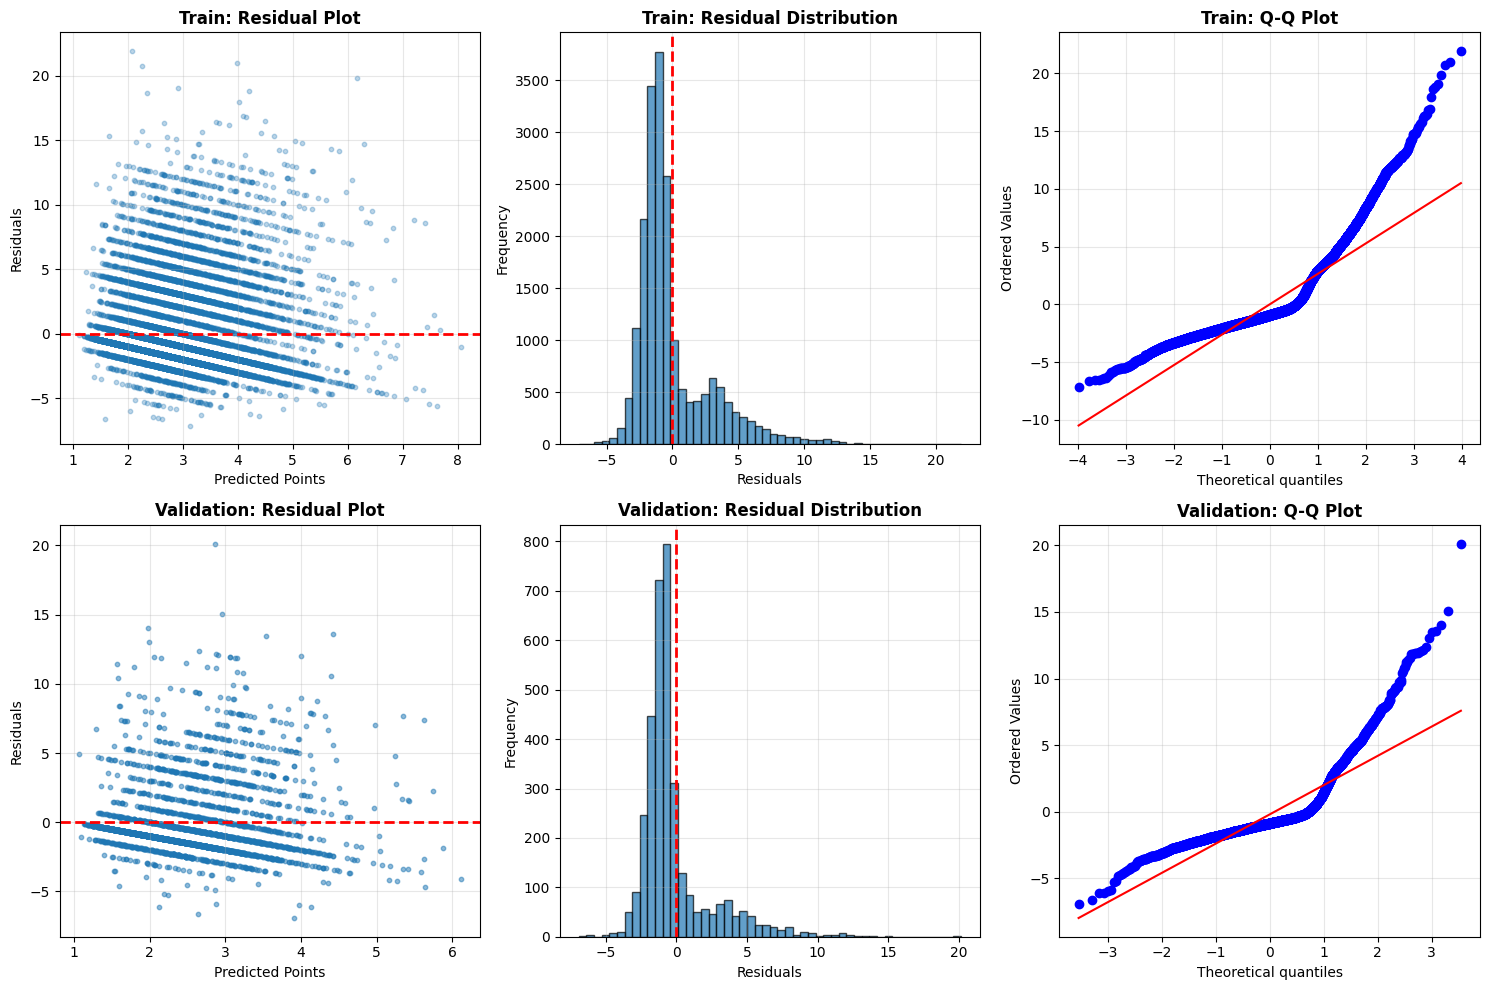


📊 Residual Statistics (Validation):
   • Mean residual:        -0.1956
   • Std residual:         2.4988
   • Min residual:         -6.9144
   • Max residual:         20.1350

✔ Residual diagnostics saved.


In [72]:
# %%
# PHASE 7.5 — Residual diagnostics

from scipy import stats

residuals_train = y_train - y_train_pred
residuals_val = y_val - y_val_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Training residuals
axes[0, 0].scatter(y_train_pred, residuals_train, alpha=0.3, s=10)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Points', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Train: Residual Plot', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals_train, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Train: Residual Distribution', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(residuals_train, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Train: Q-Q Plot', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Validation residuals
axes[1, 0].scatter(y_val_pred, residuals_val, alpha=0.5, s=10)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Points', fontsize=10)
axes[1, 0].set_ylabel('Residuals', fontsize=10)
axes[1, 0].set_title('Validation: Residual Plot', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(residuals_val, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Validation: Residual Distribution', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

stats.probplot(residuals_val, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Validation: Q-Q Plot', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Residual Statistics (Validation):")
print(f"   • Mean residual:        {residuals_val.mean():.4f}")
print(f"   • Std residual:         {residuals_val.std():.4f}")
print(f"   • Min residual:         {residuals_val.min():.4f}")
print(f"   • Max residual:         {residuals_val.max():.4f}")

print("\n✔ Residual diagnostics saved.")

In [73]:

# PHASE 8 — Export predictions


#df_out = df.copy()
#df_out["Prediction_For_GW"] = df_out["Gameweek"] + 1
#df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
#df_out["Total_Points_Predicted"] = y_all_pred.round(4)
#df_out["Error"] = (df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"]).abs()

#keep_cols = [
#    "Player UUID", "Player Name", "Web Name",
#    "season", "Prediction_For_GW", "Opponent Difficulty",
#    "Total_Points_Actual", "Total_Points_Predicted", "Error", "Split"
#]

#df_final = df_out[keep_cols]
#df_final.to_csv(OUT_DIR / "lasso_predictions.csv", index=False, encoding="utf-8-sig")

#df_final[df_final["Split"]=="Train"].to_csv(OUT_DIR/"lasso_train.csv", index=False)
#df_final[df_final["Split"]=="Validation"].to_csv(OUT_DIR/"lasso_validation.csv", index=False)

#df[["Player UUID","season","Gameweek","Split"]].to_csv(OUT_DIR/"lasso_split.csv", index=False)

#print("✔ LASSO predictions exported.")

In [74]:
# PHASE 8 — Export predictions (WITHOUT Naive Prediction)

df_out = df.copy()
df_out["Prediction_For_GW"] = df_out["Gameweek"] + 1
df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = y_all_pred.round(4)
df_out["Error"] = (df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"]).abs()

keep_cols = [
    "Player UUID", "Player Name", "Web Name",
    "season", "Prediction_For_GW", "Opponent Difficulty",
    "Total_Points_Actual", "Total_Points_Predicted",
    "Error", "Split"
]

df_final = df_out[keep_cols]

# Export main predictions
df_final.to_csv(OUT_DIR / "lasso_predictions.csv", index=False, encoding="utf-8-sig")

# Export train/validation subsets
df_final[df_final["Split"] == "Train"].to_csv(OUT_DIR / "lasso_train.csv", index=False, encoding="utf-8-sig")
df_final[df_final["Split"] == "Validation"].to_csv(OUT_DIR / "lasso_validation.csv", index=False, encoding="utf-8-sig")

# Export split assignments
df[["Player UUID", "season", "Gameweek", "Split"]].to_csv(OUT_DIR / "lasso_split.csv", index=False, encoding="utf-8-sig")

print("\n✔ LASSO predictions exported (no Naive Prediction).")



✔ LASSO predictions exported (no Naive Prediction).


In [76]:

# PHASE 9 — Update Model_Performance.csv

MODEL_PERF_PATH = Path("../output/model_performance/Model_Performance.csv")

if MODEL_PERF_PATH.exists():
    perf = pd.read_csv(MODEL_PERF_PATH)
    perf = perf[~perf["Model"].str.contains("LASSO", na=False)]
    
    baseline = perf[perf["Model"]=="Rolling Average (TotalPoints)"]
    baseline_mae = baseline["MAE_Validation"].iloc[0] if len(baseline)>0 else val_mae
else:
    perf = pd.DataFrame()
    baseline_mae = val_mae

relative_impr = (baseline_mae - val_mae) / baseline_mae

new_row = pd.DataFrame([{
    "Model": "LASSO Regression",
    "MAE_Train": round(train_mae, 5),
    "MAE_Validation": round(val_mae, 5),
    "RMSE_Train": round(train_rmse, 5),
    "RMSE_Validation": round(val_rmse, 5),
    "Relative_Improvement_vs_Baseline": round(relative_impr, 5),
    "Features_Used": int((lasso.coef_ != 0).sum()),
}])

perf = pd.concat([perf, new_row], ignore_index=True)


# Remove old columns that should no longer exist
cols_to_remove = ["Alpha", "Total_Features"]
for col in cols_to_remove:
    if col in perf.columns:
        perf = perf.drop(columns=[col])

perf.to_csv(MODEL_PERF_PATH, index=False, encoding="utf-8-sig")

print("✔ Model_Performance updated with extended metrics.")
print(f"\n   → Alpha: {lasso.alpha_:.6f}")
print(f"   → Features: {int((lasso.coef_ != 0).sum())} / {len(lasso.coef_)}")


✔ Model_Performance updated with extended metrics.

   → Alpha: 0.015199
   → Features: 19 / 47
